# Atividade PI - Entrega 2

## Introdução
Este trabalho consiste na implementação de um modelo supervisionado e um não supervisionado para classificar (por tipo de efeito) e agrupar as imagens do dataset de fotos com efeitos, respectivamente.\
\
Para o modelo supervisionado, planejo implementar uma ResNet, como na atividade 5. Já para o modelo não supervisionado, utilizarei uma combinação de PCA e K-means no vetor de características da ResNet (saída da camada de pooling imediatamente antes das camadas fully connected finais).

## Parte 1: leitura do dataset

Para obter um objeto Dataset das imagens associadas a seus labels, utilizarei a classe ImageFolder do pytorch, cujo propósito é justamente ler uma árvore de diretórios de imagens em que cada diretório corresponde a um efeito.\
\
Um problema imediato que surge nesta etapa é que, para serem utilizadas no modelo ResNet, as imagens de entrada precisam possuir as mesmas dimensões. Portanto, realizarei uma operação de "resize" na leitura do dataset, que redimensiona todas as imagens para um tamanho específico (no caso, 1512x1512). Porém, isso também pode impactar negativamente os resultados do modelo, uma vez que as imagens perderão suas proporções originais.

In [24]:
import random
import torch
import sys
import os
import torchinfo
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing as mp
import pytorch_lightning as pl

from glob import glob
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchmetrics import Accuracy
from torchsummary import summary
from sklearn.metrics import classification_report

In [2]:
transformacoes = transforms.Compose([
    transforms.Resize((231, 231)), # menor dimensão dos arquivos de imagem
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root="./photos", transform = transformacoes);

len_treino = int(0.8 * len(dataset)) # divisao 80% 20%
len_val = len(dataset) - len_treino

dataset_treino, dataset_val = random_split(
    dataset,
    [len_treino, len_val],
)

### Exibindo imagens

In [3]:
training_example = random.choice(dataset_treino)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([3, 231, 231])
Label: 11
Maior valor de intensidade da imagem: tensor(0.9608)
Menor valor de intensidade da imagem: tensor(0.0431)


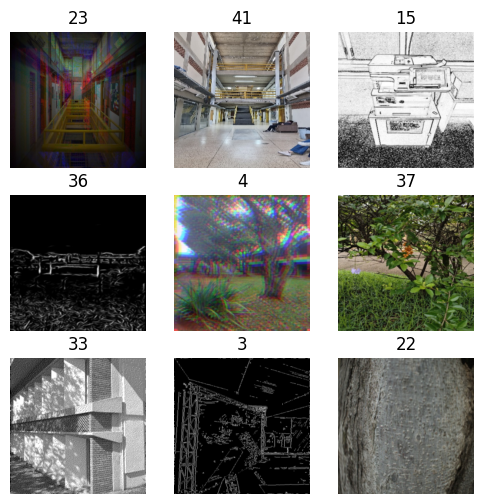

In [32]:
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(dataset_treino)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(np.transpose(img, (1, 2, 0)), vmin=0, vmax=1)
plt.show()

É possível verificar a leitura correta do dataset, porém vale notar que as imagens tiveram suas proporções distorcidas.

## Parte 2: Aprendizado supervisionado

### Hiperparâmetros

In [7]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 16,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 42,  # number of classes
           "nin": 3,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 16
nworkers: 20
nout: 42
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


OBS: utilizei batch size de 16 pois foi o que minha GPU aguentou.

### Data Module

In [8]:
class EffectsDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = dataset_treino
        self.val = dataset_val

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train,
                            batch_size=self.hparams.batch_size,
                            num_workers=self.hparams.nworkers,
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          num_workers=self.hparams.nworkers,
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

Verifica leitura de dataset através do dataloader e imprime um batch:

Shape do batch: torch.Size([16, 3, 231, 231])


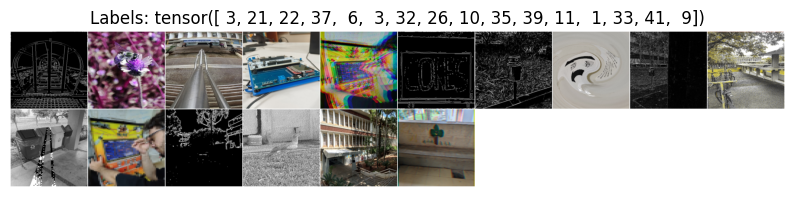

In [9]:
# DEBUG DATA MODULE
data_module = EffectsDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo o modelo

In [10]:
cnn_model = models.resnet18(weights=None)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout']) # ajusta número de features de saída (= classes)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Lightning Module

Classe para facilitar treinamento do modelo, definindo o que acontece com um batch após cada etapa.

In [11]:
class TrainEffects(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando o modelo

In [12]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainEffects(hparams)
data = EffectsDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/tur/.venvs/ea979/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 6GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_

Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 16
nworkers: 20
nout: 42
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tur/.venvs/ea979/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 9: 100%|██████████| 385/385 [00:27<00:00, 14.02it/s, v_num=3, val_loss=3.280, val_acc=0.507]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 385/385 [00:27<00:00, 14.01it/s, v_num=3, val_loss=3.280, val_acc=0.507]


### Testando o modelo nos dados de validação

In [21]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

# Load trained model
model = TrainEffects.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = EffectsDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()

        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs/Test_ResNet_1-epoch=6-val_acc=0.55.ckpt


### Análise dos Resultados

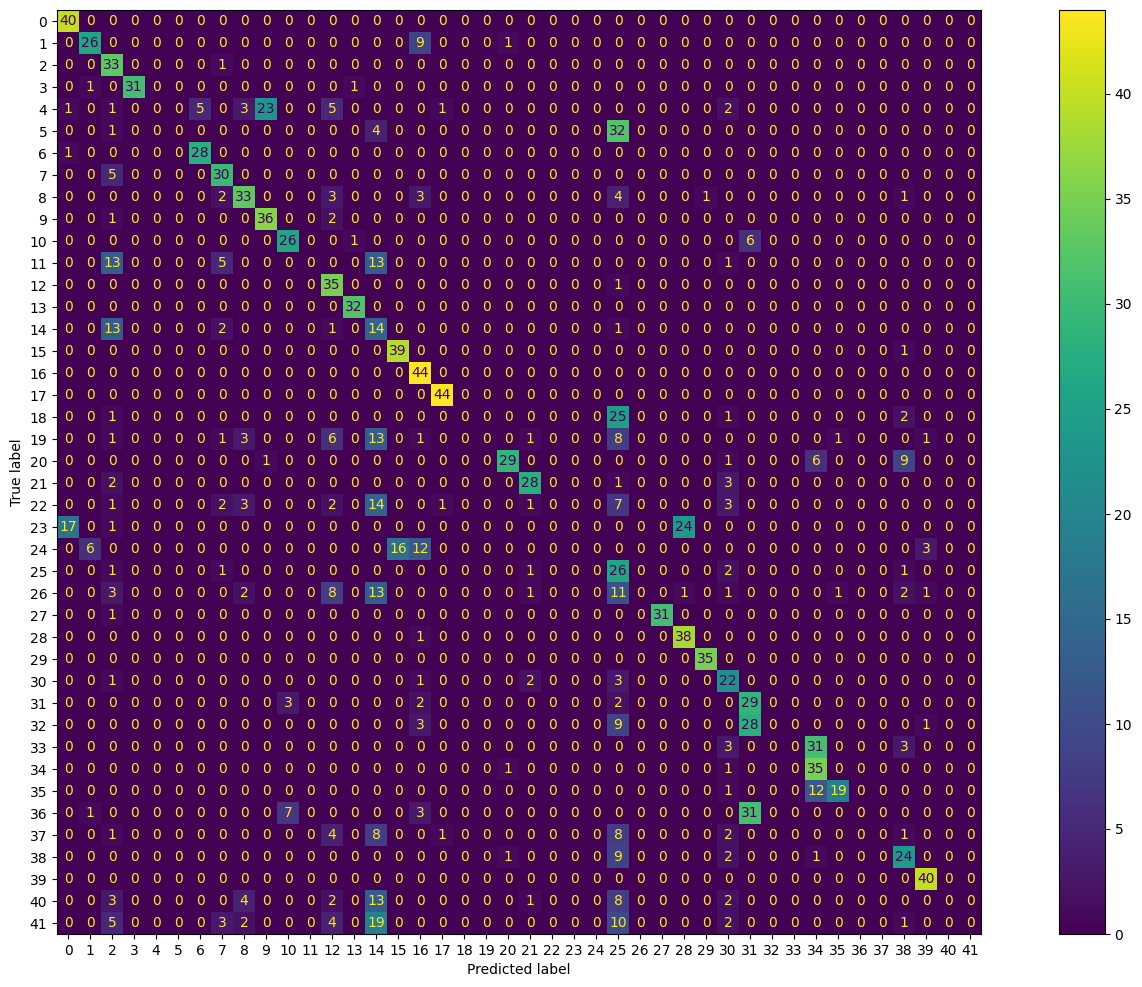


Métricas de classificação: 
              precision    recall  f1-score   support

           0       0.68      1.00      0.81        40
           1       0.76      0.72      0.74        36
           2       0.38      0.97      0.54        34
           3       1.00      0.94      0.97        33
           4       0.00      0.00      0.00        41
           5       0.00      0.00      0.00        37
           6       0.85      0.97      0.90        29
           7       0.64      0.86      0.73        35
           8       0.66      0.70      0.68        47
           9       0.60      0.92      0.73        39
          10       0.72      0.79      0.75        33
          11       0.00      0.00      0.00        32
          12       0.49      0.97      0.65        36
          13       0.94      1.00      0.97        32
          14       0.13      0.45      0.20        31
          15       0.71      0.97      0.82        40
          16       0.56      1.00      0.72        4

/home/tur/.venvs/ea979/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tur/.venvs/ea979/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tur/.venvs/ea979/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(42)),
                                display_labels=np.arange(42))
fig = disp.plot(ax=None).figure_
fig.set_size_inches(20, 12)
plt.show()

# Métricas
print("\nMétricas de classificação: ")
print(classification_report(y_trues_val, y_labels_val))

O modelo obteve um desempenho decepcionante, com uma acurácia total de 0.55.
Em 6 das classes, o modelo obteve um recall de 1, classificando todas as imagens dessas classes corretamente. Em contrapartida, o modelo não utilizou 15 das classes disponíveis durante a classificação, incluindo aquela que corresponde às imagens inalteradas.

Em alguns casos, o modelo cometeu falhas de certa forma justificáveis, devido à semelhança entre efeitos. Por exemplo, o efeito número 23 (246955_restricted_chromatic_aberration_and_vignette) implementa aberração cromática e vinheta. Nas classificações do modelo, todas as imagens cujo label real era 23 foram classificadas ou como 0 (175807_futuro), que implementa aberração cromática, ou como 28 (257234_gloomy_effect) que implementa vinheta.

Visando obter melhores resultados, algumas medidas poderiam ser tomadas:
- aumentar o número de camadas do modelo
- aumentar o número de épocas do modelo (ou outros hiperparâmetros, como learning rates e weight decay)
- revisar pré-processamento de imagens, substituindo "resize" por "random crop", uma vez que a perda de proporções da imagem pode ter prejudicado o desempenho do modelo, principalmente para efeitos dependentes da posição do pixel em relação ao centro (como distorções radiais)
- buscar outro tipo de cnn/modelo

## Parte 3: Aprendizado não supervisionado

Não tive tempo de realizar essa tarefa, porém a ideia seria utilizar PCA e K-means no vetor de características da cnn treinada acima para tentar visualizar a clusterização e tirar conclusões.